In [32]:
from matplotlib import pyplot as plt
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

from utils import show_img,classification_model_measurements

random_seed = 42

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Scaling
X_train = X_train / 255.0
X_test = X_test / 255.0

In [3]:
print("X_train.shape  => ",X_train.shape)
print("X_test.shape  => ",X_test.shape)
print("y_train.shape  => ",y_train.shape)
print("y_test.shape  => ",y_test.shape)

X_train.shape  =>  (60000, 28, 28)
X_test.shape  =>  (10000, 28, 28)
y_train.shape  =>  (60000,)
y_test.shape  =>  (10000,)


### No Nulls

In [4]:
np.isnan(X_train).any(),np.isnan(X_test).any()

(np.False_, np.False_)

### Balanced Dataset

In [5]:
values, counts = np.unique(y_train, return_counts=True)
print("Training set labels and counts:", values, counts)

values, counts = np.unique(y_test, return_counts=True)
values, counts
print("Test set labels and counts:", values, counts)

Training set labels and counts: [0 1 2 3 4 5 6 7 8 9] [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
Test set labels and counts: [0 1 2 3 4 5 6 7 8 9] [ 980 1135 1032 1010  982  892  958 1028  974 1009]


### Show sample of data

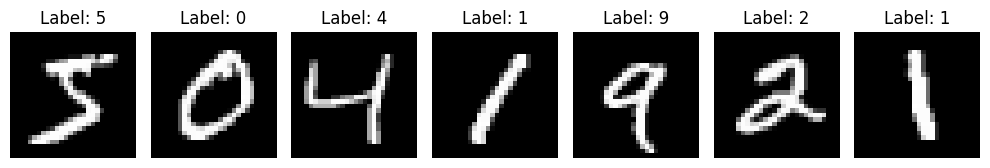

In [6]:
show_img(X_train,y_train,7)

### we need to use One Hot Encoder here

In [7]:
y_test[0:5]

array([7, 2, 1, 0, 4], dtype=uint8)

### One Hot Encoder

In [8]:
y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)
y_test[0:5]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [26]:
model = Sequential(
    [
        Flatten(input_shape=(28, 28)),
        Dense(units = 128,activation = 'relu'),
        Dropout(0.3),
        Dense(units = 64,activation = 'relu'),
        Dropout(0.3),
        Dense(units = 10,activation = 'softmax'),
    ]
)

model.compile(
    loss = 'categorical_crossentropy' , 
    optimizer='adam',
    metrics=['accuracy'] ,
)


In [45]:
early_stop  = EarlyStopping(monitor='val_loss', patience=4 ,restore_best_weights=True)

In [46]:
history = model.fit(
    X_train,
    y_train,
    batch_size=128,
    epochs=50,
    validation_split=0.2,
    callbacks = [early_stop],
    verbose=1
)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9796 - loss: 0.0616 - val_accuracy: 0.9773 - val_loss: 0.0896
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9808 - loss: 0.0609 - val_accuracy: 0.9781 - val_loss: 0.0813
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9812 - loss: 0.0587 - val_accuracy: 0.9784 - val_loss: 0.0854
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9822 - loss: 0.0566 - val_accuracy: 0.9788 - val_loss: 0.0862
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9825 - loss: 0.0556 - val_accuracy: 0.9787 - val_loss: 0.0837
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9821 - loss: 0.0550 - val_accuracy: 0.9786 - val_loss: 0.0883


In [47]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0791
Test Accuracy: 0.9780


In [48]:
y_t_pred = model.predict(X_train)
y_pred = model.predict(X_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


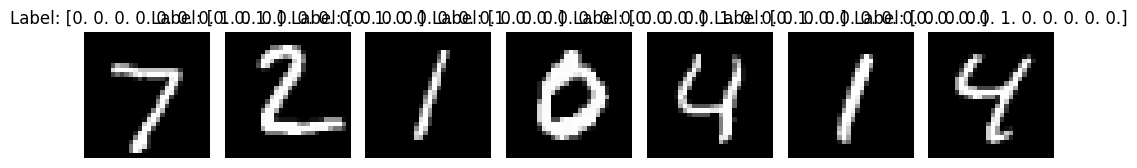

In [49]:
show_img(X_test,y_test,7)

In [50]:
[np.argmax(y_pred[i]) for i in range(7)]

[np.int64(7),
 np.int64(2),
 np.int64(1),
 np.int64(0),
 np.int64(4),
 np.int64(1),
 np.int64(4)]

In [56]:
y_test_labels = np.argmax(y_test, axis=1)
y_pred_labels = np.argmax(y_pred, axis=1)
y_train_labels = np.argmax(y_train, axis=1)
y_t_pred_labels = np.argmax(y_t_pred, axis=1)
classification_model_measurements(y_train_labels,y_t_pred_labels,y_test_labels,y_pred_labels)

************ MODEL EVALUATION METRICS ************

                  ACCURACY SCORE                  
--------------------------------------------------
Training  => 99.21%
Testing   => 97.80%

                 CONFUSION MATRIX                 
--------------------------------------------------
Training:
[[5889    0    6    1    0    1   12    2   11    1]
 [   0 6722    5    2    2    0    1    4    6    0]
 [   4    2 5926    8    1    0    3    7    7    0]
 [   0    0   34 6060    0   15    0    4   10    8]
 [   3    6    2    0 5781    1   12    3    4   30]
 [   2    0    6   25    0 5356   15    2    5   10]
 [   2    1    1    0    3    9 5901    0    1    0]
 [   1   13   19    8    2    2    0 6212    0    8]
 [   2    7    6   10    2   11    4    2 5798    9]
 [   4    4    2    9   15   12    0   15    9 5879]]

Testing:
[[ 970    0    1    2    0    0    4    1    2    0]
 [   0 1125    3    1    0    0    1    0    5    0]
 [   3    1 1011    6    2    0    2    5    2

### Saveing Model

In [54]:
joblib.dump(model, "../model/mnist_model.pkl")

['../model/mnist_model.pkl']